# Stimulation Window Condition × Accuracy — Session 3

| Condition | Trials | Stimulation window | Description |
|---|---|---|---|
| **COND1** | T3, T4, T7, T9 | Fixation → Stimulus (before choice) | Stim ON during encoding |
| **COND2** | T6, T8, T10, T12 | Choice + Feedback | Stim ON during recall/feedback |

**Verified from Events.csv:**
- COND1: T3(acc=1), T4(acc=0), T7(acc=0), T9(acc=0) → 1/4 correct
- COND2: T6(acc=1), T8(acc=1), T10(acc=1), T12(acc=0) → 3/4 correct

Stats: Fisher's Exact p-value + Cohen's d (binary acc)

## Cell 1 — Imports & Config

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import fisher_exact
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 180,
    'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

# ── Paths ────────────────────────────────────────────────────────────────
JSON_S3   = r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json'
CSV_S3    = r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv'
EVENTS_S3 = r'C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv'
OUT_DIR   = r'C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3'

# ── Condition trial lists (cross-verified) ───────────────────────────────
COND1_TRIALS = [3, 4, 7, 9]    # Stim ON during Fixation→Stimulus (encoding)
COND2_TRIALS = [6, 8, 10, 12]  # Stim ON during Choice + Feedback (recall)

STIM_THRESHOLD = 2.0
STIM_FRAC_MIN  = 0.50

COL_C1 = '#1A56DB'   # Cond1 blue
COL_C2 = '#E65100'   # Cond2 orange
COL_OK = '#2166AC'   # correct dot
COL_ER = '#D6604D'   # incorrect dot

print('Config OK')

Config OK


## Cell 2 — Load Session 3 + Classify Conditions

In [3]:
# ── Alignment pipeline ───────────────────────────────────────────────────
with open(JSON_S3) as f: report = json.load(f)
eprime = pd.read_csv(CSV_S3,    encoding='utf-8-sig', low_memory=False)
ev     = pd.read_csv(EVENTS_S3, encoding='utf-8-sig', low_memory=False)

stim_tick = None
for stream in report['BrainSenseLfp']:
    prev = None
    for pkt in stream['LfpData']:
        curr = pkt['Left']['mA']
        if prev is not None and prev == 0.0 and curr > 0.0:
            stim_tick = pkt['TicksInMs']; break
        prev = curr
    if stim_tick: break

welcome_ms = int(eprime['Welcome.TargetOnsetTime'].iloc[0])
offset     = stim_tick - welcome_ms
def to_rel(ms): return float(ms) + offset - stim_tick

ticks, mAs = [], []
for stream in report['BrainSenseLfp']:
    for pkt in stream['LfpData']:
        ticks.append(pkt['TicksInMs'])
        mAs.append(pkt['Left']['mA'])
ticks = np.array(ticks, float); mAs = np.array(mAs, float)
order = np.argsort(ticks)
ticks_rel = ticks[order] - stim_tick
mAs       = mAs[order]

def stim_frac(t0, t1):
    """Fraction of [t0,t1] with mA >= threshold. Nearest-sample fallback."""
    if t0 is None or t1 is None or t1 <= t0: return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    tr, tm = ticks_rel[mask], mAs[mask]
    if len(tr) < 2:
        idx = int(np.argmin(np.abs(ticks_rel - (t0+t1)/2)))
        return 1.0 if mAs[idx] >= STIM_THRESHOLD else 0.0
    dt = np.diff(tr); mid = (tm[:-1]+tm[1:])/2
    total = tr[-1]-tr[0]
    return float(np.sum(dt[mid >= STIM_THRESHOLD]) / total) if total > 0 else 0.0

def ev_first(etype, tn):
    r = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
    return to_rel(float(r.iloc[0]['Time_ms'])) if not r.empty else None

def ev_all_rel(etype, tn):
    r = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
    return [to_rel(float(x)) for x in r['Time_ms'].tolist()]

# ── Build trial records ──────────────────────────────────────────────────
ALL_TARGETS = COND1_TRIALS + COND2_TRIALS
rows = []
for tn in ALL_TARGETS:
    r = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
    if r.empty: continue
    r = r.iloc[0]
    acc = int(r['ACC']); nd = int(r['Num_Digits'])
    cresp = str(int(r['CRESP'])).zfill(nd)
    resp  = str(int(r['RESP'])).zfill(nd)

    fix_starts  = ev_all_rel('Fixation Start', tn)
    stim_starts = ev_all_rel('Stimulus Start', tn)
    stim_ends   = ev_all_rel('Stimulus End',   tn)
    cs  = ev_first('Choice Start',   tn)
    ce  = ev_first('Choice End',     tn)
    fb_s= ev_first('Feedback Start', tn)
    fb_e= ev_first('Feedback End',   tn)

    # Cond1 windows: all Fixation→StimulusStart + all StimulusStart→StimulusEnd
    fix_fracs  = [stim_frac(fs, ss) for fs, ss in zip(fix_starts, stim_starts)]
    stim_fracs = [stim_frac(ss, se) for ss, se in zip(stim_starts, stim_ends)]
    cond1_on   = any(f >= STIM_FRAC_MIN for f in fix_fracs+stim_fracs)

    # Cond2 windows: Choice + Feedback
    ch_frac = stim_frac(cs, ce)
    fb_frac = stim_frac(fb_s, fb_e)
    cond2_on = (ch_frac >= STIM_FRAC_MIN) or (fb_frac >= STIM_FRAC_MIN)

    condition = 'COND1' if tn in COND1_TRIALS else 'COND2'
    rows.append(dict(
        trial=tn, nd=nd, acc=acc,
        presented=cresp[::-1], cresp=cresp, resp=resp,
        condition=condition,
        cond1_stim_on=cond1_on, cond2_stim_on=cond2_on,
        ch_frac=ch_frac, fb_frac=fb_frac,
        fix_fracs=fix_fracs, stim_fracs=stim_fracs,
    ))

df = pd.DataFrame(rows)
print(df[['trial','nd','acc','presented','resp','condition',
          'cond1_stim_on','cond2_stim_on']].to_string(index=False))

 trial  nd  acc presented resp condition  cond1_stim_on  cond2_stim_on
     3   3    1       151  151     COND1           True          False
     4   3    0       324  432     COND1           True          False
     7   3    0       324  432     COND1           True          False
     9   3    0       325  532     COND1           True          False
     6   3    1       125  521     COND2          False           True
     8   3    1       141  141     COND2          False           True
    10   3    1       251  152     COND2           True           True
    12   3    0       243  324     COND2          False           True


## Cell 3 — Statistics

In [4]:
def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a)<2 or len(b)<2: return np.nan
    pooled = np.sqrt(((len(a)-1)*np.var(a,ddof=1)+(len(b)-1)*np.var(b,ddof=1))/(len(a)+len(b)-2))
    return float((np.mean(a)-np.mean(b))/pooled) if pooled>0 else np.nan

def sig_stars(p):
    if np.isnan(p): return 'N/A'
    if p<0.001: return '***'
    if p<0.01:  return '**'
    if p<0.05:  return '*'
    return 'ns'

def effect_label(d):
    if np.isnan(d): return 'N/A'
    v = abs(d)
    if v>=0.8: return 'large'
    if v>=0.5: return 'medium'
    if v>=0.2: return 'small'
    return 'negligible'

c1 = df[df['condition']=='COND1']['acc'].values.astype(float)
c2 = df[df['condition']=='COND2']['acc'].values.astype(float)

n1, nc1 = len(c1), int(c1.sum())
n2, nc2 = len(c2), int(c2.sum())

_, p = fisher_exact([[nc1, n1-nc1], [nc2, n2-nc2]])
d    = cohens_d(c1, c2)

print('='*55)
print('  COND1 (Stim ON: Fixation→Stimulus / encoding)')
print(f'  Trials: {COND1_TRIALS}')
print(f'  Accuracy: {nc1}/{n1} ({nc1/n1*100:.0f}%)')
print()
print('  COND2 (Stim ON: Choice + Feedback / recall)')
print(f'  Trials: {COND2_TRIALS}')
print(f'  Accuracy: {nc2}/{n2} ({nc2/n2*100:.0f}%)')
print()
print(f'  Fisher\'s Exact p = {p:.4f}  {sig_stars(p)}')
print(f'  Cohen\'s d        = {d:+.3f}  ({effect_label(d)})')
print(f'  Direction: {"COND2 > COND1" if nc2/n2 > nc1/n1 else "COND1 >= COND2"}')
print('='*55)

  COND1 (Stim ON: Fixation→Stimulus / encoding)
  Trials: [3, 4, 7, 9]
  Accuracy: 1/4 (25%)

  COND2 (Stim ON: Choice + Feedback / recall)
  Trials: [6, 8, 10, 12]
  Accuracy: 3/4 (75%)

  Fisher's Exact p = 0.4857  ns
  Cohen's d        = -1.000  (large)
  Direction: COND2 > COND1


## Cell 4 — Plot: Accuracy Comparison

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\condition_comparison_S3.png


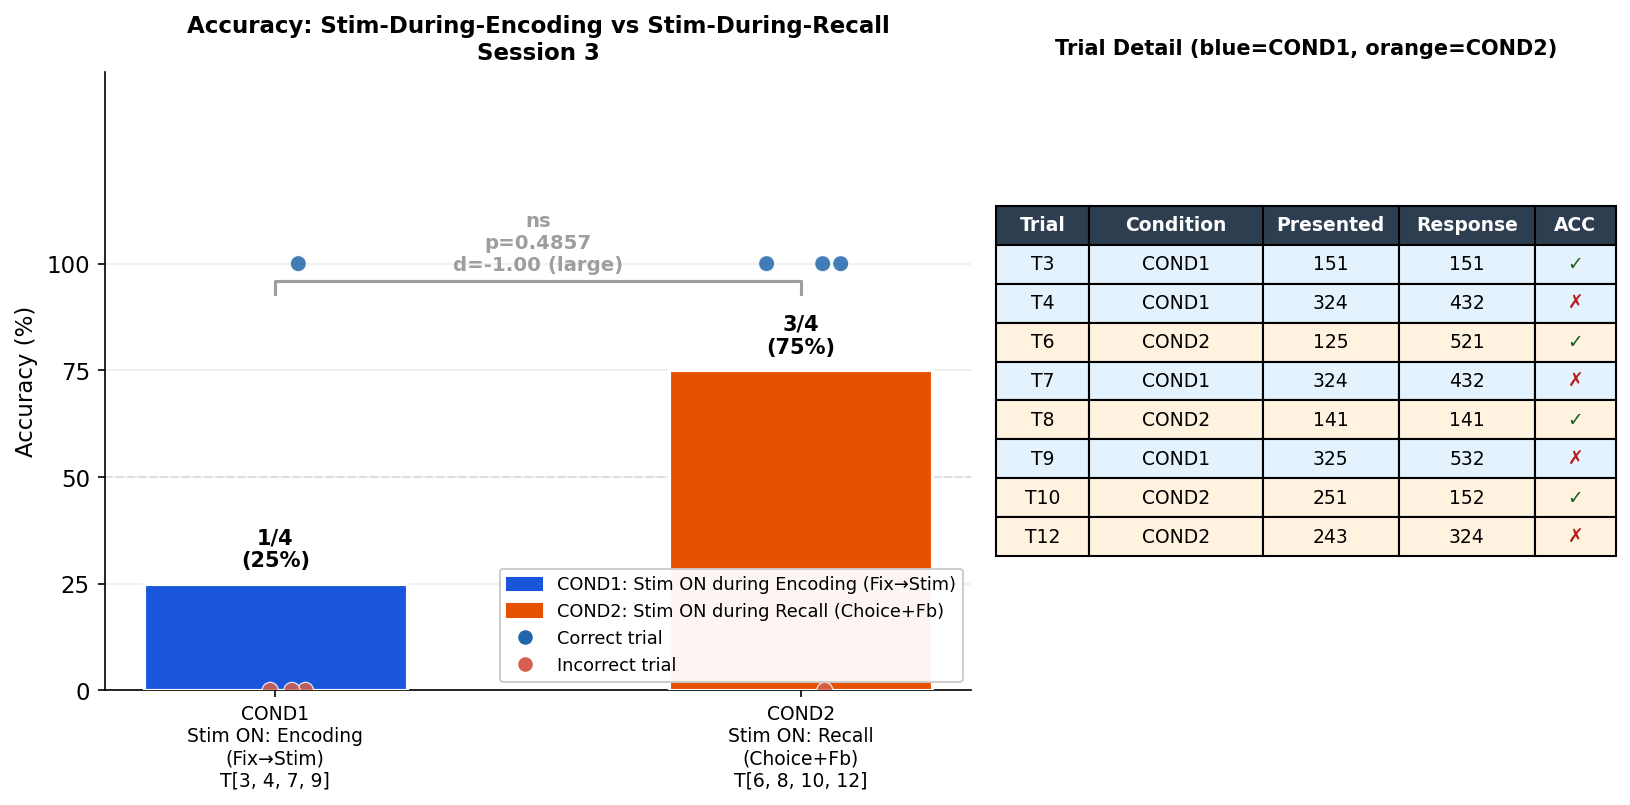

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), facecolor='white',
                          gridspec_kw=dict(width_ratios=[1.4, 1]))

# ── Left: bar + jitter ───────────────────────────────────────────────────
ax = axes[0]
acc_pcts = [nc1/n1*100, nc2/n2*100]
colors   = [COL_C1, COL_C2]
xs = [0, 1]

ax.bar(xs, acc_pcts, width=0.50, color=colors, zorder=3, edgecolor='white', lw=1.5)

rng = np.random.default_rng(42)
for xi, grp_acc in [(0, c1), (1, c2)]:
    jit = rng.uniform(-0.08, 0.08, len(grp_acc))
    dot_cols = [COL_OK if a else COL_ER for a in grp_acc]
    ax.scatter(xi+jit, grp_acc*100, c=dot_cols, s=60, zorder=5,
               edgecolors='white', lw=0.6, alpha=0.85)

for xi, nc, nt, pct in [(0,nc1,n1,acc_pcts[0]),(1,nc2,n2,acc_pcts[1])]:
    ax.text(xi, pct+3, f'{nc}/{nt}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bracket
y_top = max(acc_pcts)+18; pad=3
bcol = '#D32F2F' if p<0.05 else '#9E9E9E'
ax.plot([0,0,1,1],[y_top,y_top+pad,y_top+pad,y_top], lw=1.5, color=bcol, zorder=6)
ax.text(0.5, y_top+pad*1.5,
        f'{sig_stars(p)}\np={p:.4f}\nd={d:+.2f} ({effect_label(d)})',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold',
        color=bcol, zorder=7)

ax.set_xticks([0,1])
ax.set_xticklabels([
    f'COND1\nStim ON: Encoding\n(Fix→Stim)\nT{COND1_TRIALS}',
    f'COND2\nStim ON: Recall\n(Choice+Fb)\nT{COND2_TRIALS}'
], fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 145)
ax.set_yticks([0,25,50,75,100])
ax.axhline(50, color='#ddd', lw=1, ls='--', zorder=1)
ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
ax.set_facecolor('white')
ax.set_title('Accuracy: Stim-During-Encoding vs Stim-During-Recall\nSession 3',
             fontsize=11, fontweight='bold')

handles = [
    mpatches.Patch(color=COL_C1, label='COND1: Stim ON during Encoding (Fix→Stim)'),
    mpatches.Patch(color=COL_C2, label='COND2: Stim ON during Recall (Choice+Fb)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_OK,
               markersize=8, label='Correct trial'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_ER,
               markersize=8, label='Incorrect trial'),
]
ax.legend(handles=handles, fontsize=8.5, loc='lower right',
          framealpha=0.95, edgecolor='#ccc')

# ── Right: trial-level detail table ─────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')
tbl_data = []
for _, r in df.sort_values('trial').iterrows():
    tbl_data.append([
        f"T{int(r['trial'])}",
        r['condition'],
        r['presented'],
        r['resp'],
        '✓' if r['acc']==1 else '✗',
    ])

tbl = ax2.table(
    cellText=tbl_data,
    colLabels=['Trial','Condition','Presented','Response','ACC'],
    cellLoc='center', loc='center',
    colWidths=[0.15,0.28,0.22,0.22,0.13]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for j in range(5):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')

for i, row in enumerate(tbl_data):
    cond = row[1]
    acc_val = row[4]
    bg = '#E3F2FD' if cond=='COND1' else '#FFF3E0'
    for j in range(5):
        tbl[i+1,j].set_facecolor(bg)
    tbl[i+1,4].set_text_props(
        color='#1B5E20' if acc_val=='✓' else '#B71C1C',
        fontweight='bold')

ax2.set_title('Trial Detail (blue=COND1, orange=COND2)',
              fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
fname = rf'{OUT_DIR}\condition_comparison_S3.png'
fig.savefig(fname)
print(f'Saved → {fname}')
plt.show()
plt.close(fig)

## Cell 5 — Window-Level Stim Fraction Detail

In [9]:
print(f"{'Trial':<7} {'Cond':<8} {'ACC':<5} {'Fix/Stim fracs (encoding)':<35} {'Choice frac':<14} {'Fb frac':<10}")
print('-'*82)

for _, r in df.sort_values('trial').iterrows():
    enc = [f'{x:.2f}' for x in r['fix_fracs'] + r['stim_fracs']]
    
    print(f"T{int(r['trial']):<5} "
          f"{r['condition']:<8} "
          f"{r['acc']:<5} "
          f"{str(enc):<35} "
          f"{r['ch_frac']:<14.2f} "
          f"{r['fb_frac']:<10.2f}")

Trial   Cond     ACC   Fix/Stim fracs (encoding)           Choice frac    Fb frac   
----------------------------------------------------------------------------------
T3     COND1    1     ['1.00', '1.00', '1.00', '1.00', '1.00', '0.00'] 0.00           0.00      
T4     COND1    0     ['0.00', '1.00', '1.00', '0.00', '1.00', '0.00'] 0.00           0.00      
T6     COND2    1     ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00'] 0.00           1.00      
T7     COND1    0     ['1.00', '1.00', '1.00', '1.00', '1.00', '0.00'] 0.00           0.00      
T8     COND2    1     ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00'] 0.00           1.00      
T9     COND1    0     ['1.00', '0.00', '0.00', '0.00', '0.00', '0.00'] 0.00           0.00      
T10    COND2    1     ['0.00', '0.00', '0.00', '0.00', '0.00', '1.00'] 1.00           1.00      
T12    COND2    0     ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00'] 0.67           0.50      
